## 1. Import thư viện và cấu hình

In [1]:
# Nếu thiếu thư viện, chạy dòng dưới đây một lần rồi restart kernel:
# !pip install tensorflow scikit-learn pandas matplotlib seaborn pillow

from pathlib import Path
import os
import random
import shutil
import json
try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive')
except Exception:
    IN_COLAB = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageOps

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
MAX_PER_CLASS = None
EPOCHS = 10
FINE_TUNE_EPOCHS = 5
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

if IN_COLAB and Path('/content/drive/MyDrive').exists():
    OUTPUT_DIR = Path('/content/drive/MyDrive/BDML/Binary/outputs_binary_classification')
else:
    OUTPUT_DIR = Path('outputs_binary_classification')

CHECKPOINT_DIR = OUTPUT_DIR / 'checkpoints'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)



print('TensorFlow:', tf.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))

Mounted at /content/drive
TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Tìm thư mục dữ liệu và tạo bảng ảnh

In [2]:
cwd = Path.cwd()

candidate_roots = [
    Path('/content/drive/MyDrive/BDML (2)/Data/Clean'),
    Path('/content/drive/MyDrive/BDML/Data/Clean'),
    cwd / 'BDML' / 'Data' / 'Clean',
    cwd,
]

# Dò thêm trong MyDrive, tối đa vài cấp folder
mydrive = Path('/content/drive/MyDrive')
if mydrive.exists():
    for p in mydrive.rglob('Data/Clean'):
        candidate_roots.append(p)

DATA_ROOT = None
print("Đang kiểm tra các đường dẫn:")

seen = set()
for candidate in candidate_roots:
    candidate = candidate.resolve()
    if candidate in seen:
        continue
    seen.add(candidate)

    enc = candidate / 'Enroachment'
    non = candidate / 'Non-enroachment'

    print(candidate, "=>", enc.exists(), non.exists())

    if enc.exists() and non.exists():
        DATA_ROOT = candidate
        break

if DATA_ROOT is None:
    raise FileNotFoundError(
        'Không tìm thấy thư mục Enroachment và Non-enroachment. '
        'Hãy kiểm tra cấu trúc Drive: BDML/Data/Clean/Enroachment và BDML/Data/Clean/Non-enroachment.'
    )

CLASS_CONFIG = {
    'Non-enroachment': {
        'class_name': 'non-encroachment',
        'label': 0
    },
    'Enroachment': {
        'class_name': 'encroachment',
        'label': 1
    },
}

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}

print('DATA_ROOT =', DATA_ROOT)

Đang kiểm tra các đường dẫn:
/content/drive/MyDrive/BDML (2)/Data/Clean => False False
/content/drive/.shortcut-targets-by-id/118OfLxg8X6kLFEwWNytq0JZA0QSmnoJ2/BDML/Data/Clean => True True
DATA_ROOT = /content/drive/.shortcut-targets-by-id/118OfLxg8X6kLFEwWNytq0JZA0QSmnoJ2/BDML/Data/Clean


In [3]:
def is_valid_image(path: Path) -> bool:
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False


rows = []
invalid_files = []

for folder_name, cfg in CLASS_CONFIG.items():
    folder = DATA_ROOT / folder_name
    files = sorted([p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS])
    valid_files = []
    for path in files:
        if is_valid_image(path):
            valid_files.append(path)
        else:
            invalid_files.append(str(path))

    rng = random.Random(SEED)
    rng.shuffle(valid_files)
    selected_files = valid_files[:MAX_PER_CLASS]

    for path in selected_files:
        rows.append({
            'path': str(path.resolve()),
            'source_folder': folder_name,
            'class_name': cfg['class_name'],
            'label': cfg['label'],
        })

df = pd.DataFrame(rows)

print('Tổng ảnh được chọn:', len(df))
display(df.groupby(['source_folder', 'class_name', 'label']).size().reset_index(name='count'))

if invalid_files:
    print('Số file ảnh lỗi bị bỏ qua:', len(invalid_files))
else:
    print('Không có ảnh lỗi.')

df.head()

Tổng ảnh được chọn: 2734


,source_folder,class_name,label,count
0,Enroachment,encroachment,1,1735
1,Non-enroachment,non-encroachment,0,999


Không có ảnh lỗi.


,path,source_folder,class_name,label
0,/content/drive/.shortcut-targets-by-id/118OfLx...,Non-enroachment,non-encroachment,0
1,/content/drive/.shortcut-targets-by-id/118OfLx...,Non-enroachment,non-encroachment,0
2,/content/drive/.shortcut-targets-by-id/118OfLx...,Non-enroachment,non-encroachment,0
3,/content/drive/.shortcut-targets-by-id/118OfLx...,Non-enroachment,non-encroachment,0
4,/content/drive/.shortcut-targets-by-id/118OfLx...,Non-enroachment,non-encroachment,0


## 3. Chia train/val/test theo tỷ lệ 70/15/15

In [4]:
train_df, temp_df = train_test_split(
    df,
    train_size=TRAIN_RATIO,
    stratify=df['label'],
    random_state=SEED,
)

relative_test_size = TEST_RATIO / (VAL_RATIO + TEST_RATIO)
val_df, test_df = train_test_split(
    temp_df,
    test_size=relative_test_size,
    stratify=temp_df['label'],
    random_state=SEED,
)

splits = {'train': train_df, 'val': val_df, 'test': test_df}

for split_name, split_df in splits.items():
    print(f'\n{split_name}: {len(split_df)} ảnh')
    print(split_df['class_name'].value_counts().sort_index())

split_info = pd.concat([
    split_df.assign(split=split_name)
    for split_name, split_df in splits.items()
])
split_info.to_csv(OUTPUT_DIR / 'image_level_split.csv', index=False)
print('\nĐã lưu file split:', OUTPUT_DIR / 'image_level_split.csv')


train: 1913 ảnh
class_name
encroachment        1214
non-encroachment     699
Name: count, dtype: int64

val: 410 ảnh
class_name
encroachment        260
non-encroachment    150
Name: count, dtype: int64

test: 411 ảnh
class_name
encroachment        261
non-encroachment    150
Name: count, dtype: int64

Đã lưu file split: /content/drive/MyDrive/BDML/Binary/outputs_binary_classification/image_level_split.csv


## 4. Xem nhanh vài ảnh mẫu

In [5]:
def show_samples(dataframe, n=8):
    sample_df = dataframe.sample(min(n, len(dataframe)), random_state=SEED)
    cols = 4
    rows = int(np.ceil(len(sample_df) / cols))
    plt.figure(figsize=(14, 3.5 * rows))
    for i, (_, row) in enumerate(sample_df.iterrows(), start=1):
        img = Image.open(row['path'])
        img = ImageOps.exif_transpose(img).convert('RGB')
        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.title(f"{row['class_name']} | label={row['label']}")
        plt.axis('off')
    plt.tight_layout()

show_samples(df, n=12)

Output hidden; open in https://colab.research.google.com to view.

## 5. Tạo TensorFlow Dataset

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.08),
    layers.RandomContrast(0.10),
], name='data_augmentation')


def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.float32)
    return image, label


def make_dataset(dataframe, training=False):
    paths = dataframe['path'].values
    labels = dataframe['label'].values.astype('float32')
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

batch_images, batch_labels = next(iter(train_ds))
print('Image batch:', batch_images.shape)
print('Label batch:', batch_labels.shape)

Image batch: (16, 224, 224, 3)
Label batch: (16,)


## 6. Khai báo 3 mô hình baseline

In [7]:
MODEL_CONFIGS = {
    'MobileNetV2': {
        'base': keras.applications.MobileNetV2,
        'preprocess': keras.applications.mobilenet_v2.preprocess_input,
    },
    'EfficientNetB0': {
        'base': keras.applications.EfficientNetB0,
        'preprocess': keras.applications.efficientnet.preprocess_input,
    },
    'ResNet50V2': {
        'base': keras.applications.ResNet50V2,
        'preprocess': keras.applications.resnet_v2.preprocess_input,
    },
}


def build_model(model_name):
    cfg = MODEL_CONFIGS[model_name]
    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = data_augmentation(inputs)
    x = layers.Lambda(cfg['preprocess'], name=f'{model_name}_preprocess')(x)

    base_model = cfg['base'](
        include_top=False,
        weights='imagenet',
        input_shape=(*IMG_SIZE, 3),
    )
    base_model.trainable = False

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(
    1,
    activation='sigmoid',
    name='encroachment_probability'
)(x)

    model = keras.Model(inputs, outputs, name=model_name)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.BinaryAccuracy(name='accuracy'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
            keras.metrics.AUC(name='auc'),
        ],
    )
    return model, base_model


for name in MODEL_CONFIGS:
    print(name)

MobileNetV2
EfficientNetB0
ResNet50V2


## 7. Train 3 mô hình và lưu checkpoint

In [8]:
histories = {}
trained_models = {}

for model_name in MODEL_CONFIGS:
    print('\n' + '=' * 80)
    print('Training:', model_name)
    print('=' * 80)

    model, base_model = build_model(model_name)
    checkpoint_path = CHECKPOINT_DIR / f'{model_name}_best.keras'

    callbacks = [
        keras.callbacks.ModelCheckpoint(
            filepath=checkpoint_path,
            monitor='val_auc',
            mode='max',
            save_best_only=True,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor='val_auc',
            mode='max',
            patience=3,
            restore_best_weights=True,
            verbose=1,
        ),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1,
    )

    histories[model_name] = history.history
    trained_models[model_name] = model

    print('Best checkpoint:', checkpoint_path)


Training: MobileNetV2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7473 - auc: 0.7811 - loss: 0.5107 - precision: 0.7683 - recall: 0.8665
Epoch 1: val_auc improved from None to 0.96008, saving model to /content/drive/MyDrive/BDML/Binary/outputs_binary_classification/checkpoints/MobileNetV2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/BDML/Binary/outputs_binary_classification/checkpoints/MobileNetV2_best.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 375s 3s/step - accuracy: 0.8212 - auc: 0.8887 - loss: 0.3940 - precision: 0.8303 - recall: 0.9028 - val_accuracy: 0.9098 - val_auc: 0.9601 - val_loss: 0.2539 - val_precision: 0.9339 - val_recall: 0.9231
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8901 - auc: 0.9451 - loss: 0.2764 - precision: 0.9047 - recall: 0.9235
Epoch 2: val_auc improved from 0.96008 to 0.96481, saving model to /content/drive/MyDrive/BDML/Binary/outputs_binary_classifi

## 8. Đánh giá trên test set

In [9]:
def get_true_labels(dataset):
    y_true = []
    for _, labels in dataset:
        y_true.extend(labels.numpy().astype(int).tolist())
    return np.array(y_true)


def evaluate_model(model, dataset, threshold=0.5):
    y_true = get_true_labels(dataset)
    y_prob = model.predict(dataset).ravel()
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1_score': f1_score(y_true, y_pred, zero_division=0),
        'auc': roc_auc_score(y_true, y_prob),
    }
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    report = classification_report(
      y_true,
      y_pred,
      target_names=['non-encroachment', 'encroachment'],
      zero_division=0,
    )
    return metrics, cm, report, y_true, y_prob, y_pred


results = []
confusion_matrices = {}
predictions = {}

def load_best_model(model_name):
    best_path = CHECKPOINT_DIR / f'{model_name}_best.keras'
    return keras.models.load_model(
        best_path,
        safe_mode=False,
        custom_objects={'preprocess_input': MODEL_CONFIGS[model_name]['preprocess']},
    )


for model_name in MODEL_CONFIGS:
    model = load_best_model(model_name)
    metrics, cm, report, y_true, y_prob, y_pred = evaluate_model(model, test_ds)
def load_best_model(model_name):
    best_path = CHECKPOINT_DIR / f'{model_name}_best.keras'
    return keras.models.load_model(
        best_path,
        safe_mode=False,
        custom_objects={'preprocess_input': MODEL_CONFIGS[model_name]['preprocess']},
    )


for model_name in MODEL_CONFIGS:
    model = load_best_model(model_name)
    metrics, cm, report, y_true, y_prob, y_pred = evaluate_model(model, test_ds)
def load_best_model(model_name):
    best_path = CHECKPOINT_DIR / f'{model_name}_best.keras'
    return keras.models.load_model(
        best_path,
        safe_mode=False,
        custom_objects={'preprocess_input': MODEL_CONFIGS[model_name]['preprocess']},
    )


for model_name in MODEL_CONFIGS:
    model = load_best_model(model_name)
    metrics, cm, report, y_true, y_prob, y_pred = evaluate_model(model, test_ds)
def load_best_model(model_name):
    best_path = CHECKPOINT_DIR / f'{model_name}_best.keras'
    return keras.models.load_model(
        best_path,
        safe_mode=False,
        custom_objects={'preprocess_input': MODEL_CONFIGS[model_name]['preprocess']},
    )


for model_name in MODEL_CONFIGS:
    model = load_best_model(model_name)
    metrics, cm, report, y_true, y_prob, y_pred = evaluate_model(model, test_ds)
    row = {'model': model_name, **metrics}
    results.append(row)
    confusion_matrices[model_name] = cm
    predictions[model_name] = {
        'y_true': y_true,
        'y_prob': y_prob,
        'y_pred': y_pred,
    }

    print('\n' + '=' * 80)
    print(model_name)
    print('=' * 80)
    print(pd.Series(metrics))
    print('\nClassification report:')
    print(report)

results_df = pd.DataFrame(results).sort_values('f1_score', ascending=False)
results_df.to_csv(OUTPUT_DIR / 'classification_results.csv', index=False)
display(results_df)

26/26 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step

MobileNetV2
accuracy     0.885645
precision    0.876761
recall       0.954023
f1_score     0.913761
auc          0.957011
dtype: float64

Classification report:
                  precision    recall  f1-score   support

non-encroachment       0.91      0.77      0.83       150
    encroachment       0.88      0.95      0.91       261

        accuracy                           0.89       411
       macro avg       0.89      0.86      0.87       411
    weighted avg       0.89      0.89      0.88       411

26/26 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step

EfficientNetB0
accuracy     0.907543
precision    0.89679

,model,accuracy,precision,recall,f1_score,auc
1,EfficientNetB0,0.907543,0.896797,0.965517,0.929889,0.960000
2,ResNet50V2,0.902676,0.890459,0.965517,0.926471,0.962605
0,MobileNetV2,0.885645,0.876761,0.954023,0.913761,0.957011


In [10]:
# Xuất log riêng cho từng mô hình

LOG_DIR = OUTPUT_DIR / 'logs'
LOG_DIR.mkdir(parents=True, exist_ok=True)

history_rows = []

for model_name in MODEL_CONFIGS:
    log_txt_path = LOG_DIR / f'{model_name}_log.txt'
    history_csv_path = LOG_DIR / f'{model_name}_history.csv'

    model_history_rows = []

    with open(log_txt_path, 'w', encoding='utf-8') as f:
        f.write(f'BÁO CÁO LOG HUẤN LUYỆN VÀ ĐÁNH GIÁ MÔ HÌNH: {model_name}\n')
        f.write('=' * 80 + '\n\n')

        f.write(f'Data root: {DATA_ROOT.resolve()}\n')
        f.write(f'Image size: {IMG_SIZE}\n')
        f.write(f'Batch size: {BATCH_SIZE}\n')
        f.write(f'Epochs: {EPOCHS}\n')
        f.write(f'Tỉ lệ chia dữ liệu: Train {TRAIN_RATIO}, Val {VAL_RATIO}, Test {TEST_RATIO}\n\n')

        f.write('Số lượng ảnh theo từng tập:\n')
        for split_name, split_df in splits.items():
            f.write(f'\n{split_name.upper()}: {len(split_df)} ảnh\n')
            f.write(str(split_df['class_name'].value_counts().sort_index()))
            f.write('\n')

        f.write('\n' + '=' * 80 + '\n')
        f.write('LỊCH SỬ HUẤN LUYỆN THEO EPOCH\n')
        f.write('=' * 80 + '\n\n')

        if model_name in histories:
            history = histories[model_name]
            num_epochs = len(history.get('loss', []))

            for epoch_idx in range(num_epochs):
                row = {
                    'model': model_name,
                    'epoch': epoch_idx + 1,
                }

                line_parts = [f"Epoch {epoch_idx + 1}"]

                for metric_name, values in history.items():
                    value = values[epoch_idx]
                    row[metric_name] = value
                    line_parts.append(f"{metric_name}: {value:.4f}")

                model_history_rows.append(row)
                history_rows.append(row)
                f.write(' | '.join(line_parts) + '\n')

        f.write('\n' + '=' * 80 + '\n')
        f.write('KẾT QUẢ TRÊN TEST SET\n')
        f.write('=' * 80 + '\n\n')

        metric_row = results_df[results_df['model'] == model_name].iloc[0]

        for metric in ['accuracy', 'precision', 'recall', 'f1_score', 'auc']:
            f.write(f"- {metric}: {metric_row[metric]:.4f}\n")

        f.write('\nConfusion matrix:\n')
        f.write(str(confusion_matrices[model_name]))
        f.write('\n')

        pred = predictions[model_name]
        report = classification_report(
            pred['y_true'],
            pred['y_pred'],
            target_names=['non-encroachment', 'encroachment'],
            zero_division=0,
        )

        f.write('\nClassification report:\n')
        f.write(report)
        f.write('\n')

    model_history_df = pd.DataFrame(model_history_rows)
    model_history_df.to_csv(history_csv_path, index=False)

    print('Đã lưu log cho', model_name)
    print('-', log_txt_path)
    print('-', history_csv_path)

# Thêm file CSV tổng hợp history của cả 3 model nếu cần so sánh chung
all_history_csv_path = LOG_DIR / 'training_history_all_models.csv'
pd.DataFrame(history_rows).to_csv(all_history_csv_path, index=False)

print('\nĐã lưu file history tổng hợp:')
print('-', all_history_csv_path)

Đã lưu log cho MobileNetV2
- /content/drive/MyDrive/BDML/Binary/outputs_binary_classification/logs/MobileNetV2_log.txt
- /content/drive/MyDrive/BDML/Binary/outputs_binary_classification/logs/MobileNetV2_history.csv
Đã lưu log cho EfficientNetB0
- /content/drive/MyDrive/BDML/Binary/outputs_binary_classification/logs/EfficientNetB0_log.txt
- /content/drive/MyDrive/BDML/Binary/outputs_binary_classification/logs/EfficientNetB0_history.csv
Đã lưu log cho ResNet50V2
- /content/drive/MyDrive/BDML/Binary/outputs_binary_classification/logs/ResNet50V2_log.txt
- /content/drive/MyDrive/BDML/Binary/outputs_binary_classification/logs/ResNet50V2_history.csv

Đã lưu file history tổng hợp:
- /content/drive/MyDrive/BDML/Binary/outputs_binary_classification/logs/training_history_all_models.csv


### So sánh các mô hình Binary Classification

Bảng so sánh

In [11]:
comparison_df = results_df.copy()

# Làm tròn số cho dễ nhìn
metric_cols = ['accuracy', 'precision', 'recall', 'f1_score', 'auc']
comparison_df[metric_cols] = comparison_df[metric_cols].round(4)

# Thêm nhận xét tự động đơn giản
def model_comment(row):
    if row['f1_score'] == comparison_df['f1_score'].max():
        return 'F1-score cao nhất, cân bằng tốt giữa Precision và Recall'
    elif row['auc'] == comparison_df['auc'].max():
        return 'AUC cao nhất, khả năng phân biệt hai lớp tốt'
    else:
        return 'Dùng để so sánh baseline'

comparison_df['nhan_xet'] = comparison_df.apply(model_comment, axis=1)

display(comparison_df)

,model,accuracy,precision,recall,f1_score,auc,nhan_xet
1,EfficientNetB0,0.9075,0.8968,0.9655,0.9299,0.9600,"F1-score cao nhất, cân bằng tốt giữa Precision..."
2,ResNet50V2,0.9027,0.8905,0.9655,0.9265,0.9626,"AUC cao nhất, khả năng phân biệt hai lớp tốt"
0,MobileNetV2,0.8856,0.8768,0.9540,0.9138,0.9570,Dùng để so sánh baseline


Biểu đồ cột so sánh Metric

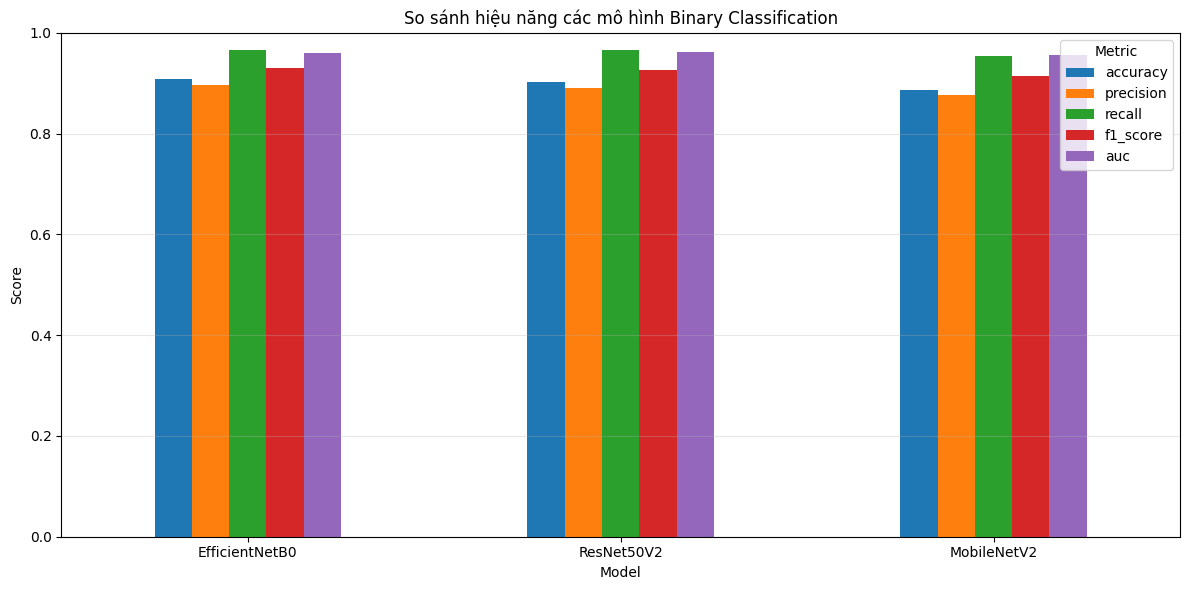

In [12]:
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1_score', 'auc']

plot_df = comparison_df.set_index('model')[metrics_to_plot]

ax = plot_df.plot(kind='bar', figsize=(12, 6))

plt.title('So sánh hiệu năng các mô hình Binary Classification')
plt.ylabel('Score')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Metric')
plt.tight_layout()

plt.savefig(OUTPUT_DIR / 'model_comparison_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

Chọn model tốt nhất

In [13]:
best_f1_model = comparison_df.sort_values('f1_score', ascending=False).iloc[0]
best_auc_model = comparison_df.sort_values('auc', ascending=False).iloc[0]

print("Mô hình tốt nhất theo F1-score:")
print(f"- Model: {best_f1_model['model']}")
print(f"- F1-score: {best_f1_model['f1_score']}")
print(f"- Accuracy: {best_f1_model['accuracy']}")
print(f"- Precision: {best_f1_model['precision']}")
print(f"- Recall: {best_f1_model['recall']}")
print(f"- AUC: {best_f1_model['auc']}")

print("\nMô hình tốt nhất theo AUC:")
print(f"- Model: {best_auc_model['model']}")
print(f"- AUC: {best_auc_model['auc']}")

Mô hình tốt nhất theo F1-score:
- Model: EfficientNetB0
- F1-score: 0.9299
- Accuracy: 0.9075
- Precision: 0.8968
- Recall: 0.9655
- AUC: 0.96

Mô hình tốt nhất theo AUC:
- Model: ResNet50V2
- AUC: 0.9626


#So sánh ban đầu và sau

In [14]:
# Test nhanh cả 3 model bằng cùng một nhóm ảnh ngẫu nhiên từ test set

MODEL_NAMES = ['MobileNetV2', 'EfficientNetB0', 'ResNet50V2']
N_SAMPLES = 6
THRESHOLD = 0.5

label_to_name = {
    0: 'non-encroachment',
    1: 'encroachment'
}

# Lấy cùng một nhóm ảnh để so sánh công bằng
sample_df = test_df.sample(
    n=min(N_SAMPLES, len(test_df)),
    random_state=None
).reset_index(drop=True)

for model_name in MODEL_NAMES:
    model = load_best_model(model_name)

    cols = 3
    rows = int(np.ceil(len(sample_df) / cols))

    plt.figure(figsize=(15, 5 * rows))

    for i, row in sample_df.iterrows():
        img_path = row['path']
        true_label = int(row['label'])
        true_name = label_to_name[true_label]

        img_show = Image.open(img_path)
        img_show = ImageOps.exif_transpose(img_show).convert('RGB')

        img_input = img_show.resize(IMG_SIZE)
        img_array = np.array(img_input).astype('float32')
        img_array = np.expand_dims(img_array, axis=0)

        prob = model.predict(img_array, verbose=0)[0][0]
        pred_label = 1 if prob >= THRESHOLD else 0
        pred_name = label_to_name[pred_label]

        is_correct = true_label == pred_label
        color = 'green' if is_correct else 'red'
        result_text = 'ĐÚNG' if is_correct else 'SAI'

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img_show)
        plt.axis('off')
        plt.title(
            f"True: {true_name}\nPred: {pred_name} ({prob:.3f})\n{result_text}",
            color=color,
            fontsize=12
        )

    plt.suptitle(f'Dự đoán ngẫu nhiên bằng model: {model_name}', fontsize=16)
    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

## 9. Confusion matrix

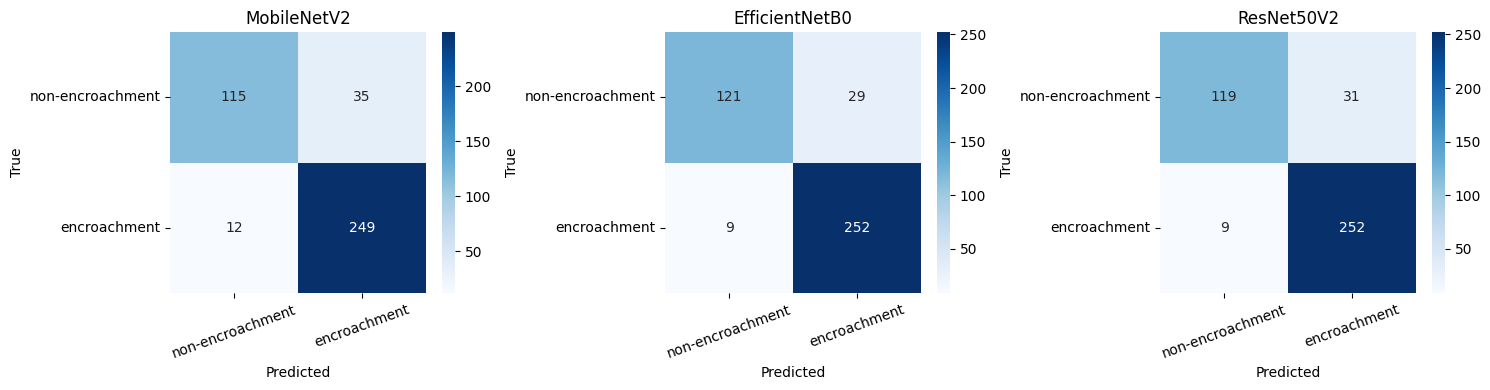

In [15]:
fig, axes = plt.subplots(1, len(confusion_matrices), figsize=(5 * len(confusion_matrices), 4))
if len(confusion_matrices) == 1:
    axes = [axes]

for ax, (model_name, cm) in zip(axes, confusion_matrices.items()):
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['non-encroachment', 'encroachment'],
        yticklabels=['non-encroachment', 'encroachment'],
        ax=ax,
    )
    ax.set_title(model_name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=20)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrices.png', dpi=200, bbox_inches='tight')
plt.show()

## 10. Vẽ learning curves

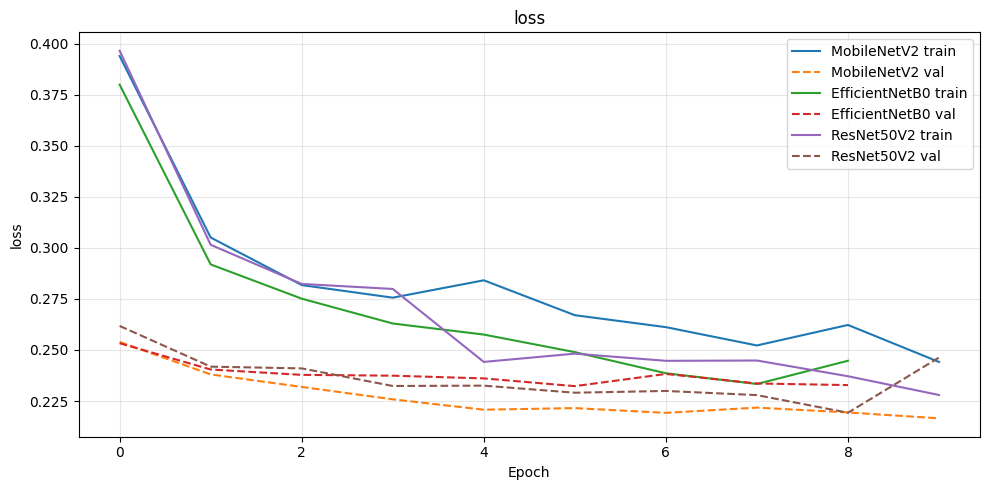

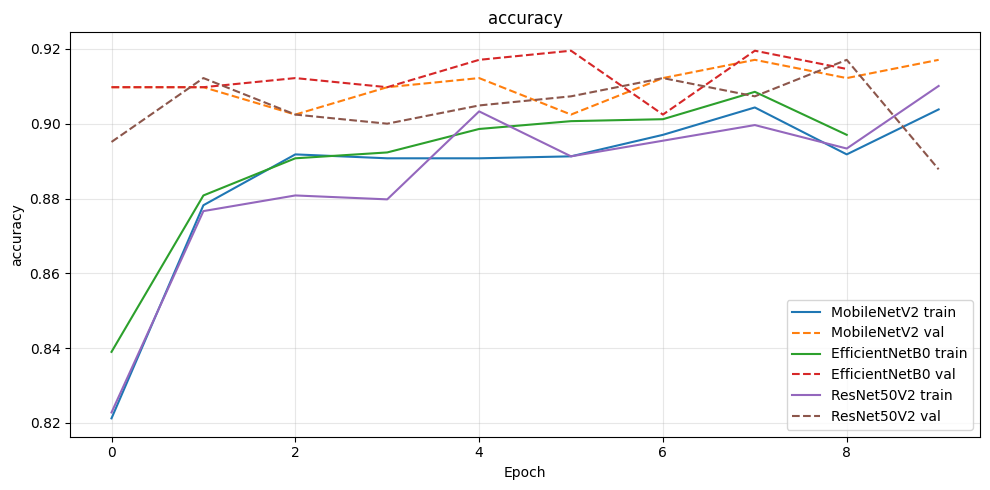

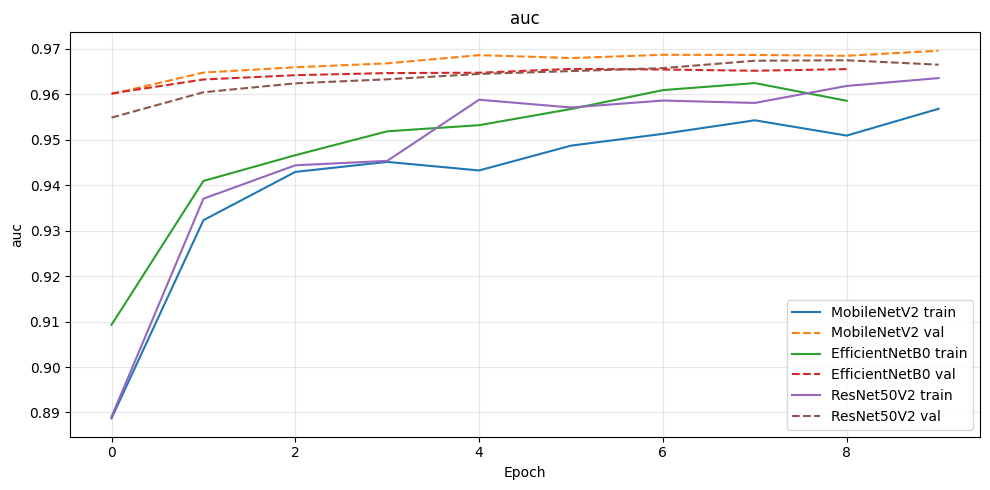

In [16]:
def plot_history(histories, metric):
    plt.figure(figsize=(10, 5))
    for model_name, history in histories.items():
        if metric in history:
            plt.plot(history[metric], label=f'{model_name} train')
        val_metric = f'val_{metric}'
        if val_metric in history:
            plt.plot(history[val_metric], linestyle='--', label=f'{model_name} val')
    plt.title(metric)
    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_history(histories, 'loss')
plot_history(histories, 'accuracy')
plot_history(histories, 'auc')

## 11. Lưu kết quả tổng hợp

In [17]:
# Xuất thêm file .keras và .pt cho mô hình tốt nhất theo F1-score
try:
    import torch
except ImportError:
    !pip install torch
    import torch

best_model_name = results_df.sort_values('f1_score', ascending=False).iloc[0]['model']
best_model = load_best_model(best_model_name)

# Lưu bản Keras chuẩn
best_keras_path = OUTPUT_DIR / 'best_model.keras'
best_model.save(best_keras_path)

# Lưu thêm file .pt cùng thư mục OUTPUT_DIR
best_pt_path = OUTPUT_DIR / 'best_model.pt'

torch.save({
    'model_name': best_model_name,
    'img_size': IMG_SIZE,
    'threshold': 0.5,
    'label_mapping': {
        0: 'non-encroachment',
        1: 'encroachment'
    },
    'keras_model_path': str(best_keras_path),
    'weights': {
        weight.name: weight.numpy()
        for weight in best_model.weights
    }
}, best_pt_path)

print('Mô hình tốt nhất:', best_model_name)
print('Đã lưu Keras model:', best_keras_path)
print('Đã lưu file PT:', best_pt_path)
summary = {
    'label_mapping': {
    'Non-enroachment': {
        'class_name': 'non-encroachment',
        'label': 0
    },
    'Enroachment': {
        'class_name': 'encroachment',
        'label': 1
    },
},
    'data_root': str(DATA_ROOT.resolve()),
    'max_per_class': MAX_PER_CLASS,
    'split_ratio': {'train': TRAIN_RATIO, 'val': VAL_RATIO, 'test': TEST_RATIO},
    'split_counts': {
        name: split_df['class_name'].value_counts().to_dict()
        for name, split_df in splits.items()
    },
    'models': list(MODEL_CONFIGS.keys()),
    'best_model': best_model_name,
    'best_model_files': {
        'keras': str(best_keras_path),
        'pt': str(best_pt_path),
    },
    'results': results_df.to_dict(orient='records'),
}

with open(OUTPUT_DIR / 'summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print('Đã lưu:')
print('-', OUTPUT_DIR / 'image_level_split.csv')
print('-', OUTPUT_DIR / 'classification_results.csv')
print('-', OUTPUT_DIR / 'summary.json')
print('-', OUTPUT_DIR / 'confusion_matrices.png')
print('-', CHECKPOINT_DIR)
print('-', OUTPUT_DIR / 'best_model.keras')
print('-', OUTPUT_DIR / 'best_model.pt')

Mô hình tốt nhất: EfficientNetB0
Đã lưu Keras model: /content/drive/MyDrive/BDML/Binary/outputs_binary_classification/best_model.keras
Đã lưu file PT: /content/drive/MyDrive/BDML/Binary/outputs_binary_classification/best_model.pt
Đã lưu:
- /content/drive/MyDrive/BDML/Binary/outputs_binary_classification/image_level_split.csv
- /content/drive/MyDrive/BDML/Binary/outputs_binary_classification/classification_results.csv
- /content/drive/MyDrive/BDML/Binary/outputs_binary_classification/summary.json
- /content/drive/MyDrive/BDML/Binary/outputs_binary_classification/confusion_matrices.png
- /content/drive/MyDrive/BDML/Binary/outputs_binary_classification/checkpoints
- /content/drive/MyDrive/BDML/Binary/outputs_binary_classification/best_model.keras
- /content/drive/MyDrive/BDML/Binary/outputs_binary_classification/best_model.pt
